In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import napari
from scipy.ndimage import median_filter
from skimage.filters import threshold_multiotsu, threshold_triangle, threshold_otsu, threshold_li, threshold_isodata, threshold_mean, threshold_minimum, threshold_yen, threshold_niblack
plt.rcParams['font.family'] = 'Arial'

In [11]:
data_dir = "../Stelzer_Torsten/niis/"

In [12]:
slice_1a = nib.load(data_dir + "CT_2025-03-03_11h19_Stelzer_capsule_1a_PEG_API.nii").get_fdata()[:, :, 500]

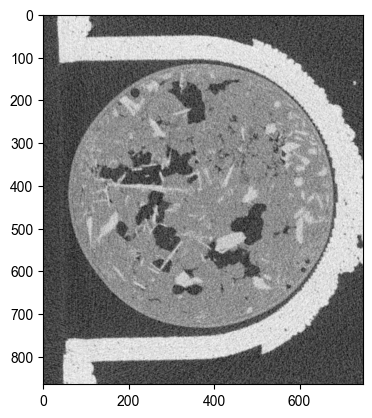

In [4]:
plt.imshow(slice_1a, cmap='Greys_r')

In [5]:
data = np.load("../Stelzer_Torsten/npys/sh_removed_1a.npy")

In [7]:
%gui qt6
napari.view_image(sh_removed_1a)

Viewer(camera=Camera(center=(0.0, np.float64(432.0), np.float64(373.5)), zoom=np.float64(1.127807486631016), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(973.0), 1.0, 0.0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(1947.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(864.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(747.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(973.0), np.float64(432.0), np.float64(373.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False, sp

In [6]:
# double median filter, takes about 5 mins
data = median_filter(data, footprint=np.ones((3, 3, 3)))
data = median_filter(data, footprint=np.ones((3, 3, 3)))

In [2]:
# np.save("../Stelzer_Torsten/npys/sh_removed_1a_medianfiltered.npy", data)
data = np.load("../Stelzer_Torsten/npys/sh_removed_1a_medianfiltered.npy")

In [7]:
%gui qt6
napari.view_image(data)

Viewer(camera=Camera(center=(0.0, np.float64(432.0), np.float64(373.5)), zoom=np.float64(1.127807486631016), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(973.0), 1.0, 0.0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(1947.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(864.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(747.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(973.0), np.float64(432.0), np.float64(373.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False, sp

In [3]:
thresh1 = threshold_multiotsu(data[data != -1], classes=3)[0]

In [4]:
(data > thresh1).shape

(1948, 865, 748)

In [ ]:
%gui qt6
napari.view_image(data > thresh1)

Viewer(camera=Camera(center=(0.0, np.float64(432.0), np.float64(373.5)), zoom=np.float64(1.127807486631016), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(973.0), 1.0, 0.0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(1947.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(864.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(747.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(973.0), np.float64(432.0), np.float64(373.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False, sp

In [5]:
def get_API_mass(alg, data, thresh1):
    thresh2 = alg(data[data > thresh1])
    regions = np.digitize(data, bins=[thresh1, thresh2])
    api_voxel_count = np.unique(regions, return_counts=True)[-1][-1]
    api_volume = api_voxel_count * (15e-6)**3 # in m3
    api_density = 1.321*1e3 # in kg/m3
    api_mass = api_density * api_volume * 1000 * 1000 # mg
    print(f"Calculated API Mass in Capsule: {api_mass} mg")
    return api_mass

In [6]:
triangle_mass = get_API_mass(threshold_triangle, data, thresh1)
otsu_mass = get_API_mass(threshold_otsu, data, thresh1)

Calculated API Mass in Capsule: 77.60516810850001 mg
Calculated API Mass in Capsule: 118.46056634775 mg


In [ ]:
li_mass = get_API_mass(threshold_li, data, thresh1)

Calculated API Mass in Capsule: 177.35343524324998 mg


In [7]:
thresh2_triangle = threshold_triangle(data[data > thresh1])
thresh2_otsu = threshold_otsu(data[data > thresh1])

In [8]:
slice_triangle = np.digitize(data[500, :, :], bins=[thresh1, thresh2_triangle])
slice_otsu = np.digitize(data[500, :, :], bins=[thresh1, thresh2_otsu])

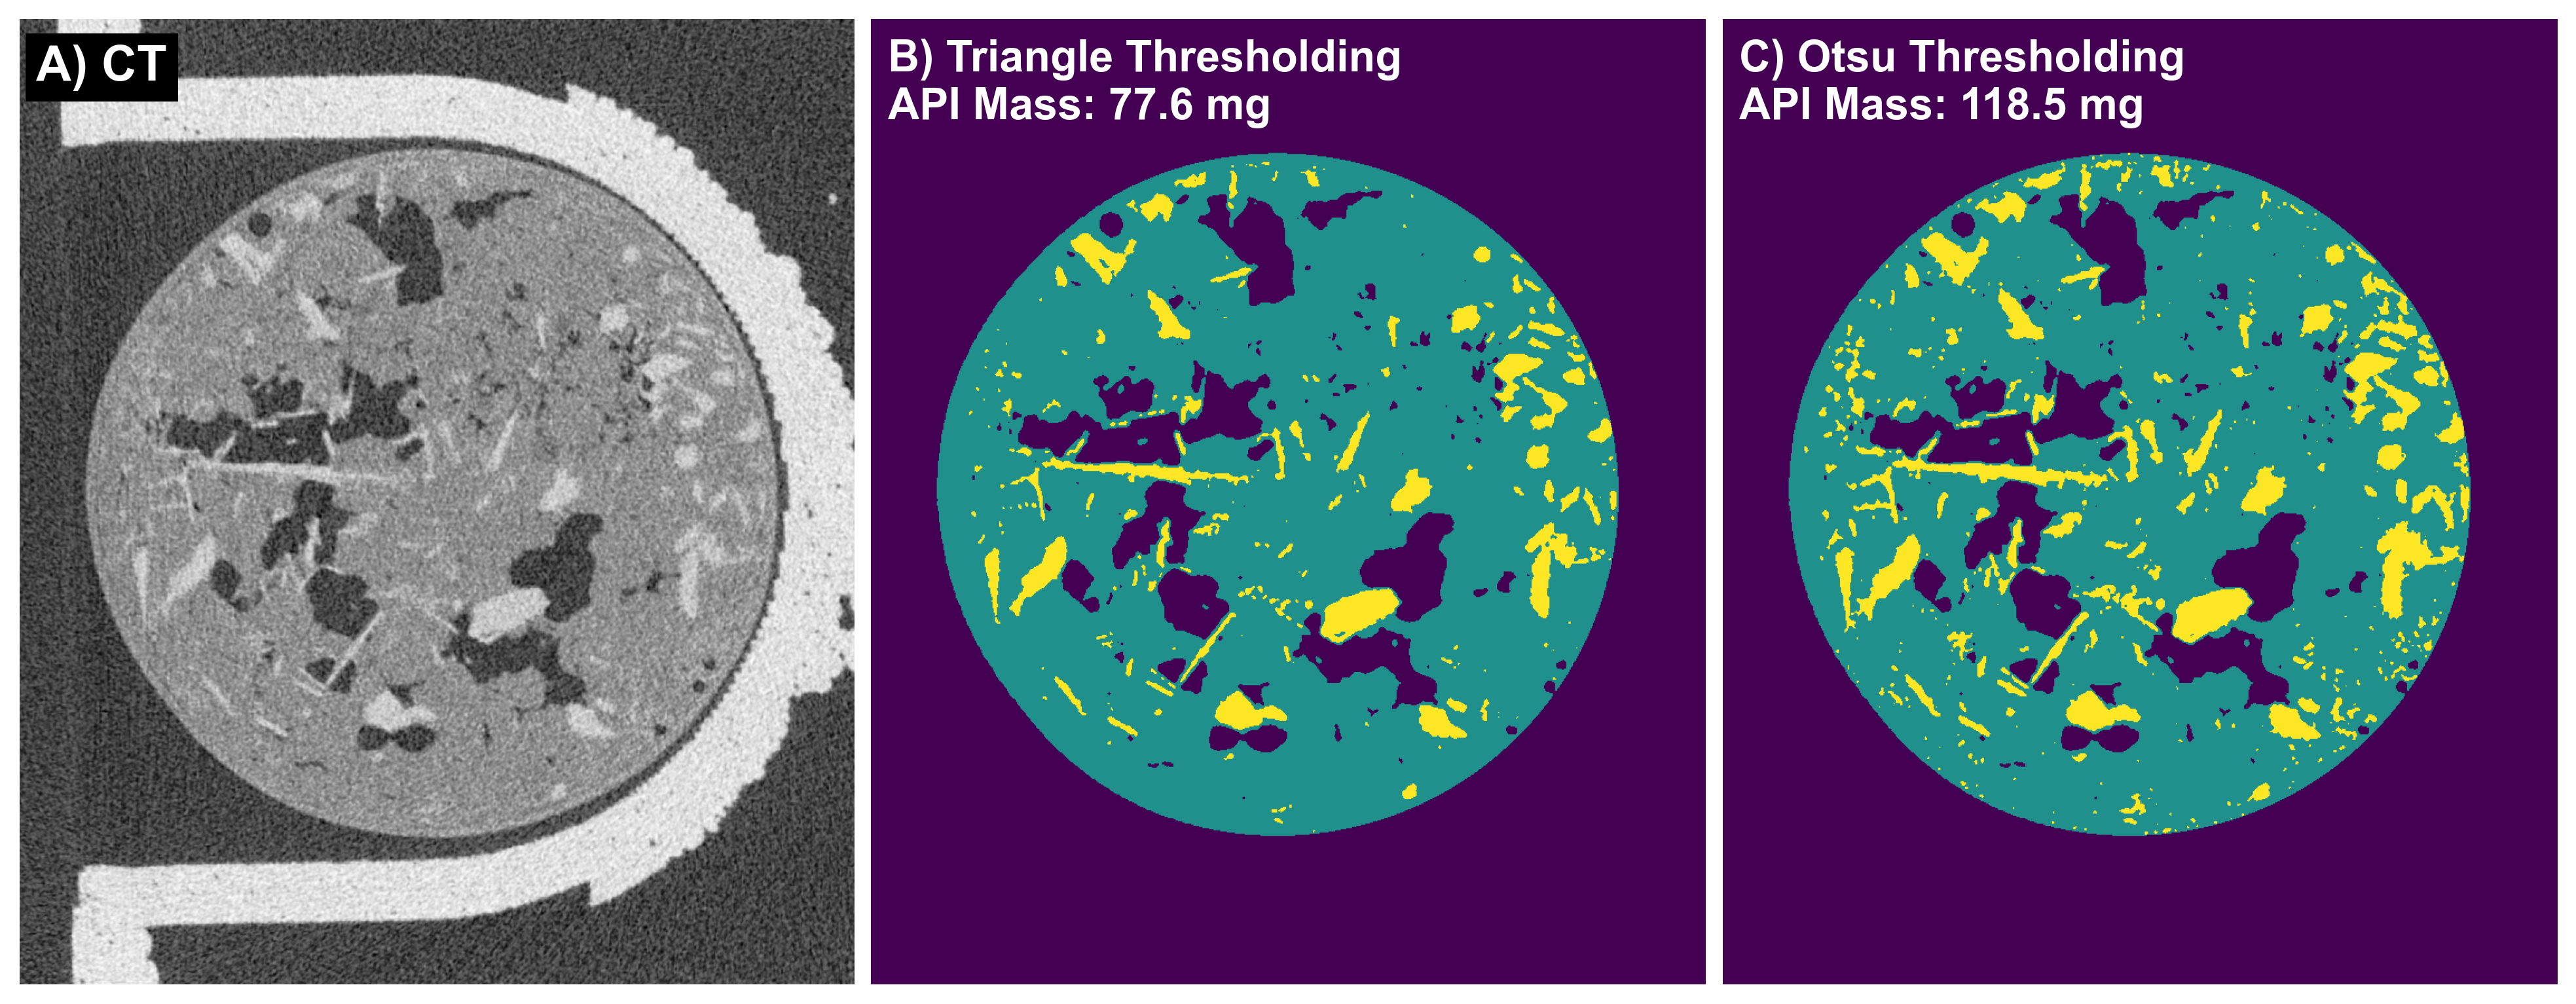

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(13, 5), constrained_layout=True, dpi=300)
fontsize = 18
axs[0].imshow(slice_1a, cmap='Greys_r')
axs[0].set_title("A) CT", fontsize=fontsize, color='white', x=0.02, y=0.92, fontweight='bold',  ha='left', bbox={'facecolor':'black', 'edgecolor':'none'})
axs[0].axis('off')
axs[1].imshow(slice_triangle, cmap='viridis')
axs[1].set_title(f"B) Triangle Thresholding\nAPI Mass: {triangle_mass:.1f} mg", 
                 fontsize=fontsize-2, color='white', x=0.02, y=0.88, fontweight='bold', ha='left')
axs[1].axis('off')
axs[2].imshow(slice_otsu, cmap='viridis')
axs[2].set_title(f"C) Otsu Thresholding\nAPI Mass: {otsu_mass:.1f} mg", 
                 fontsize=fontsize-2, color='white', x=0.02, y=0.88, fontweight='bold', ha='left')
axs[2].axis('off')
# fig.text(0.56, 0.715, f"API Mass: {triangle_mass:.1f} mg", fontsize=fontsize-2, ha='center', va='center', color='white', fontweight='bold')
# fig.text(0.89, 0.715, f"API Mass: {otsu_mass:.1f} mg", fontsize=fontsize-2, ha='center', va='center', color='white', fontweight='bold')
fig.savefig("imgs/S2_comparing_thresholding_algs.png", dpi=300)